# 03 - User Behavior Analysis

**Project:** E-Commerce User Behavior Analysis & Recommendation System  
**Notebook purpose:** Explore user behavior patterns through visualizations, then engineer the behavioral features needed for segmentation, collaborative filtering, A/B testing, and all downstream modeling notebooks.

---

## Environment Setup

This notebook was run on **Kaggle Notebooks** using the cleaned dataset produced by `02_initial_data_preprocessing.ipynb`.

### To reproduce this notebook

1. Go to the repository on GitHub:  
   [ecommerce-behavior-analysis](https://github.com/halleepham/ecommerce-behavior-analysis)
2. Download `notebooks/03_user_behavior_analysis.ipynb`
3. Open a Kaggle notebook and attach the cleaned dataset output from `02_initial_data_preprocessing.ipynb` as an input
4. Run all cells top to bottom

### Data path

All cells in this notebook use the following path to access the cleaned data:

    /kaggle/input/datasets/kylenaluan/ecommerce-data-from-oct-and-nov-cleaned/ecommerce_oct_nov_clean.parquet

### Python version and key libraries

| Library | Version |
|---|---|
| Python | 3.12.12 |
| pandas | 2.3.3 |
| numpy | 2.0.2 |
| pyplot | 3.10.0 |
| seaborn | 0.13.2 |

---

## Scope

This notebook provides visualizations to understand how users interact with the store. Covers event distribution, conversion funnel, temporal activity patterns, and product/category/brand popularity.


In [1]:
import os
import sys
import pandas as pd
import numpy as np
import gc
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Data Path
CLEAN_FILE = '/kaggle/input/datasets/kylenaluan/ecommerce-data-from-oct-and-nov-cleaned/ecommerce_oct_nov_clean.parquet'

# Constants
SEED = 5530
TOP_N = 10

# Plotting Parameters
sns.set_theme(style='whitegrid', palette='muted', rc={'figure.figsize':(12,5)})

# Verify File Exists
print(f'File exists: {os.path.exists(CLEAN_FILE)}')

print(f'Python : {sys.version}')
print(f'pandas : {pd.__version__}')
print(f'numpy  : {np.__version__}')
print(f'pyplot  : {plt.matplotlib.__version__}')
print(f'seaborn  : {sns.__version__}')

File exists: True
Python : 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
pandas : 2.3.3
numpy  : 2.0.2
pyplot  : 3.10.0
seaborn  : 0.13.2


In [2]:
df = pd.read_parquet(CLEAN_FILE)

# Get main section of category code (e.g., electronics, appliances, etc.)
# Replace the 'category_code' column with the top-level category since the full code won't be needed in this notebook
df['main_category'] = df['category_code'].apply(
    lambda x: x.split('.', 1)[0]
)
df.drop(columns=['category_code'], inplace=True)
gc.collect()

# Create separate time columns
df['hour']       = df['event_time'].dt.hour
df['day_of_week']= df['event_time'].dt.day_name()
df['date']       = df['event_time'].dt.date
df['month']      = df['event_time'].dt.month

print('Shape :', df.shape)
print('\nData types:')
print(df.dtypes)
print('\nFirst 5 rows:')
df.head(5)

Shape : (109820004, 13)

Data types:
event_time       datetime64[ns, UTC]
event_type                    object
product_id                     int32
category_id                    int64
brand                         object
price                        float32
user_id                        int32
user_session                  object
main_category                 object
hour                           int32
day_of_week                   object
date                          object
month                          int32
dtype: object

First 5 rows:


,event_time,event_type,product_id,category_id,brand,price,user_id,user_session,main_category,hour,day_of_week,date,month
0,2019-10-01 00:00:00+00:00,view,44600062,2103807459595387724,shiseido,35.790001,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c,unknown,0,Tuesday,2019-10-01,10
1,2019-10-01 00:00:00+00:00,view,3900821,2053013552326770905,aqua,33.200001,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc,appliances,0,Tuesday,2019-10-01,10
2,2019-10-01 00:00:01+00:00,view,17200506,2053013559792632471,unknown,543.099976,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8,furniture,0,Tuesday,2019-10-01,10
3,2019-10-01 00:00:01+00:00,view,1307067,2053013558920217191,lenovo,251.740005,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713,computers,0,Tuesday,2019-10-01,10
4,2019-10-01 00:00:04+00:00,view,1004237,2053013555631882655,apple,1081.979980,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d,electronics,0,Tuesday,2019-10-01,10


---

# User Behavior Analysis

Common Y-axis formatting function to count units by millions

In [3]:
# Axis Formatting - https://stackoverflow.com/a/67237328
def formatter(x, pos):
    return str(round(x / 1e6, 1))

## Event Type Distribution

How many views, cart additions, and purchases are there in each month?

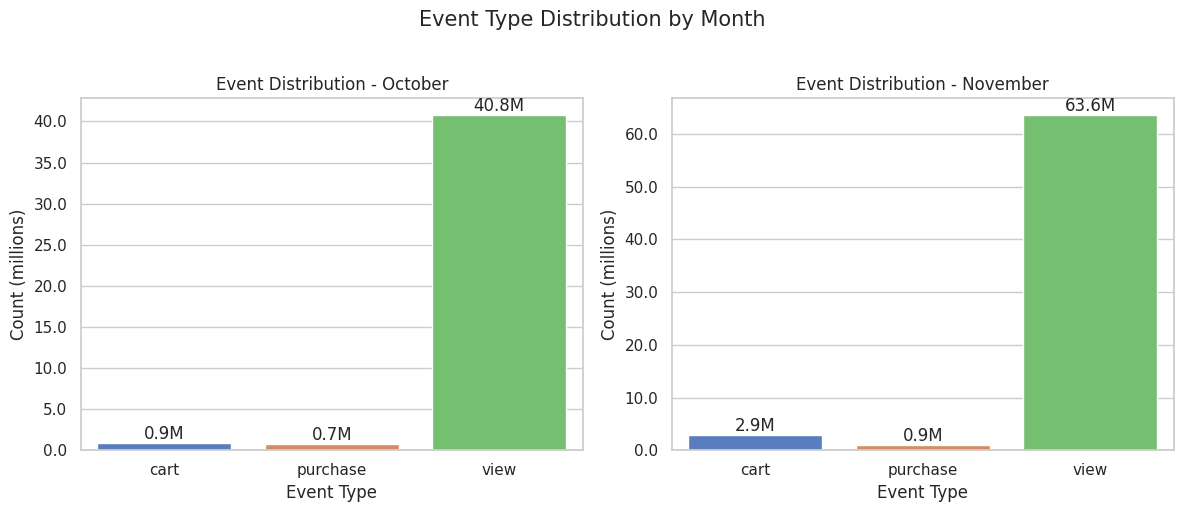

In [53]:
def label_formatter(x):
    return f'{x / 1e6:.1f}M'

event_counts = (
    df.groupby(['month', 'event_type'])
    .size()
    .reset_index(name='count')
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax0 = sns.barplot(data=event_counts[event_counts['month'] == 10],
            x='event_type',
            y='count',
            hue='event_type',
            ax=axes[0])
ax1 = sns.barplot(data=event_counts[event_counts['month'] == 11],
            x='event_type',
            y='count',
            hue='event_type',
            ax=axes[1])

axes[0].set_title('Event Distribution - October')
axes[0].set_xlabel('Event Type')
axes[0].yaxis.set_major_formatter(formatter)
axes[0].set_ylabel('Count (millions)')

for container in ax0.containers:
    ax0.bar_label(container, fmt=label_formatter)

axes[1].set_title('Event Distribution - November')
axes[1].set_xlabel('Event Type')
axes[1].yaxis.set_major_formatter(formatter)
axes[1].set_ylabel('Count (millions)')

for container in ax1.containers:
    ax1.bar_label(container, fmt=label_formatter)

plt.suptitle('Event Type Distribution by Month', fontsize=15, y=1.02)

plt.tight_layout()
plt.savefig('event_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [68]:
sums = event_counts.groupby('month')['count'].sum()

sums

month
10    42418544
11    67401460
Name: count, dtype: int64

In [67]:
event_counts['percentage'] = (
    event_counts['count'] / event_counts.groupby('month')['count'].transform('sum') * 100
).round(2)

event_counts

,month,event_type,count,percentage
0,10,cart,898443,2.12
1,10,purchase,742773,1.75
2,10,view,40777328,96.13
3,11,cart,2930018,4.35
4,11,purchase,916930,1.36
5,11,view,63554512,94.29


In [ ]:
del event_counts
gc.collect()

* October had roughly 42.5M events versus 67.3M in November — a 58% between months.
* Across both months, views dominate at 94–96% of all events, while purchases account for only 1.4–1.8%.
  * This extreme imbalance between browsing and buying is normal for e-commerce platforms.

## Conversion Funnel

What percentage of views lead to cart additions, and what percentage of cart additions lead to purchases?
* This was previously calculated in the initial dataset exploration prior to cleaning and processing.

In [6]:
funnel_counts = (
    df.groupby(['month', 'event_type'])
    .size()
    .unstack(fill_value=0)
    .rename(columns={'view': 'View', 'cart': 'Cart', 'purchase': 'Purchase'})
)
funnel_counts.index = funnel_counts.index.map({10: 'October', 11: 'November'})

# Conversion rates
funnel_counts['View → Cart %']     = (funnel_counts['Cart']     / funnel_counts['View']  * 100).round(2)
funnel_counts['Cart → Purchase %'] = (funnel_counts['Purchase'] / funnel_counts['Cart']  * 100).round(2)
funnel_counts['View → Purchase %'] = (funnel_counts['Purchase'] / funnel_counts['View']  * 100).round(2)

print('--- Conversion Funnel ---')
print(funnel_counts.to_string())

--- Conversion Funnel ---
event_type     Cart  Purchase      View  View → Cart %  Cart → Purchase %  View → Purchase %
month                                                                                       
October      898443    742773  40777328           2.20              82.67               1.82
November    2930018    916930  63554512           4.61              31.29               1.44


In [ ]:
del funnel_counts()
gc.collect()

* Similar results to conversion funnel before pre-processing
* November has a higher view → cart rate, but a lower cart → purchase rate.
  * Users may have been more actively considering buying items in November
  * Users were adding more items to cart but following through less often.
  * This pattern is consistent with holiday wishlist behavior.

## Daily Activity Over Time

How does the number of events change day by day across both months? This helps identify spikes like Black Friday.

In [13]:
daily_counts = (
    df.groupby(['date', 'event_type'])
    .size()
    .reset_index(name='count')
)
daily_counts['date'] = pd.to_datetime(daily_counts['date'])

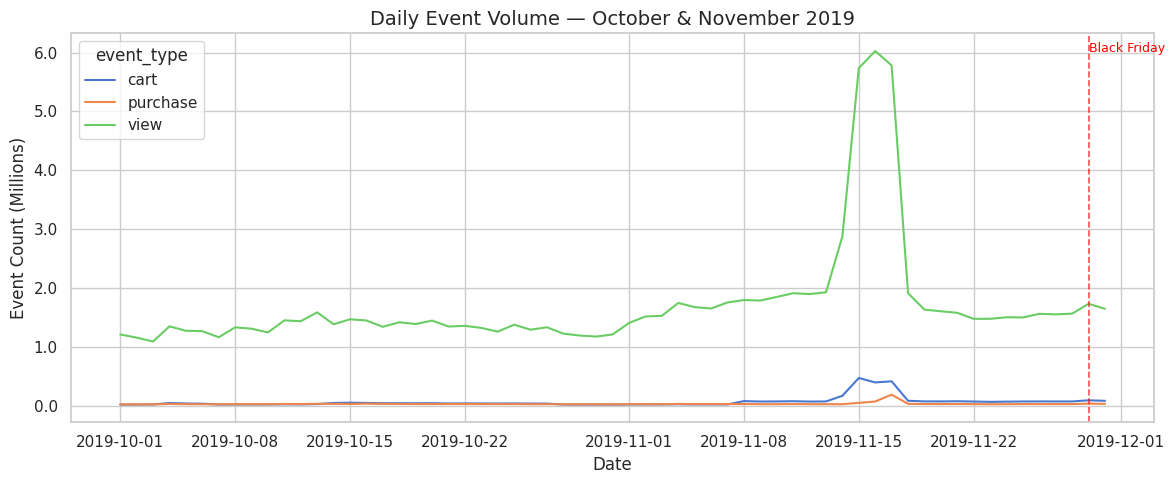

In [54]:
activity_lp = sns.lineplot(data=daily_counts, x='date', y='count', hue='event_type')

plt.axvline(pd.Timestamp('2019-11-29'), color='red', linestyle='--', linewidth=1.2, alpha=0.7)
plt.text(pd.Timestamp('2019-11-29'), ax.get_ylim()[1] * 0.95,
        'Black Friday', color='red', fontsize=9, ha='left')

plt.title('Daily Event Volume — October & November 2019', fontsize=14)
plt.xlabel('Date')
plt.gca().yaxis.set_major_formatter(formatter)
plt.ylabel('Event Count (Millions)')

plt.tight_layout()
act_lp_fig = activity_lp.get_figure()
act_lp_fig.savefig('daily_activity.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
del daily_counts
gc.collect()

* Daily event volume in November is consistently higher than October.
* There is a pronounced spike around November 11–15.
  * This likely reflects early holiday season promotions.
* A second visible uptick appears toward the end of November consistent with Black Friday activity.
* The gap between view volume and purchase volume widens in November, which is consistent with the observations in the conversion funnel.

## Hourly Activity Heatmap

Which hours and days of the week are most active? This informs the time-sensitive recommendation system in notebook 07.

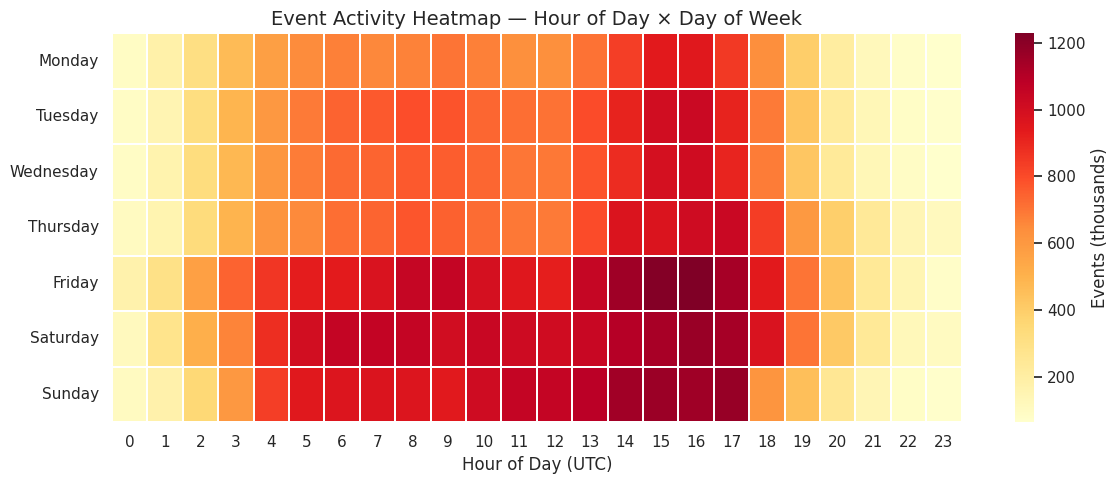

In [55]:
DOW_ORDER = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

heatmap_data = (
    df.groupby(['day_of_week', 'hour'])
    .size()
    .reset_index(name='count')
    .pivot(index='day_of_week', columns='hour', values='count')
    .reindex(DOW_ORDER)
)

activity_hm = sns.heatmap(
    heatmap_data / 1e3,
    cmap='YlOrRd',
    linewidths=0.3,
    cbar_kws={'label': 'Events (thousands)'}
)
plt.title('Event Activity Heatmap — Hour of Day × Day of Week', fontsize=14)
plt.xlabel('Hour of Day (UTC)')
plt.ylabel('')

plt.tight_layout()
act_hm_fig = activity_hm.get_figure()
act_hm_fig.savefig('hourly_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
del heatmap_data
gc.collect()

* Activity is highest in the evening hours between roughly 14:00 and 18:00 UTC across all days of the week.
* Weekday and weekend patterns are broadly similar, however there is higher activity in the morning hours on weekends, as well as slightly higher activity during the previously mentioned peak hours.

## Top Categories and Brands

Which categories and brands are most viewed and purchased?

In [8]:
# Function to return the top n of an brand/category by the event type
def top_n_by_event(col, event_type, n=TOP_N):
    mask = (df['event_type'] == event_type) & (df[col] != 'unknown')
    filtered = df.loc[mask, col]
    return (
        filtered
        .groupby(filtered)
        .count()
        .sort_values(ascending=False)
        .head(n)
    )

### Top 10 categories for views and purchases

In [17]:
top_cat_views = top_n_by_event('main_category', 'view')
top_cat_pur = top_n_by_event('main_category', 'purchase')

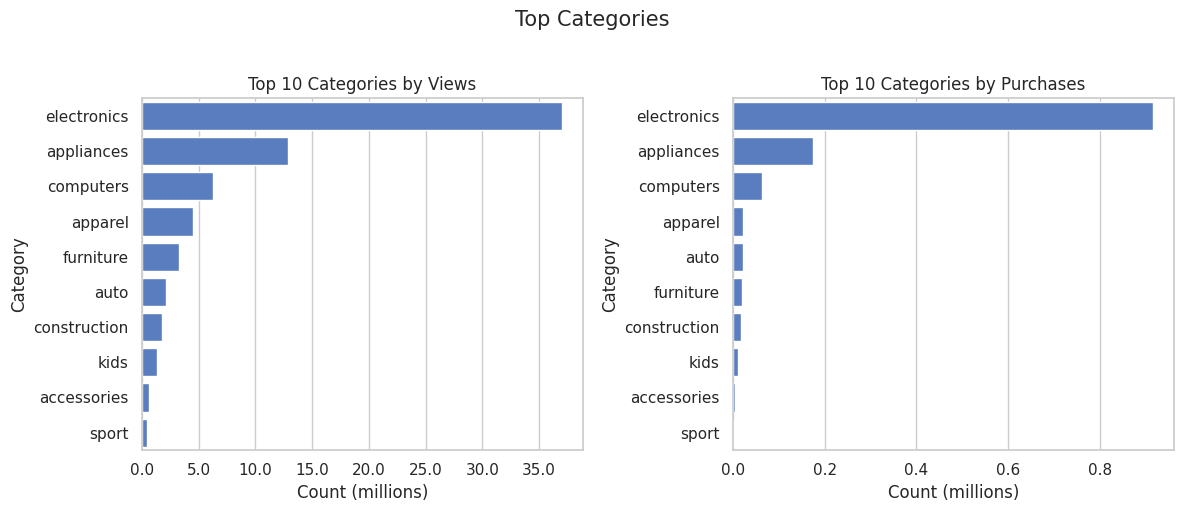

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax0 = sns.barplot(
            x=top_cat_views.values,
            y=top_cat_views.index,
            ax=axes[0])
ax1 = sns.barplot(
            x=top_cat_pur.values,
            y=top_cat_pur.index,
            ax=axes[1])

axes[0].set_title('Top 10 Categories by Views')
axes[0].set_xlabel('Count (millions)')
axes[0].xaxis.set_major_formatter(formatter)
axes[0].set_ylabel('Category')

axes[1].set_title('Top 10 Categories by Purchases')
axes[1].set_xlabel('Count (millions)')
axes[1].xaxis.set_major_formatter(formatter)
axes[1].set_ylabel('Category')

plt.suptitle('Top Categories', fontsize=15, y=1.02)

plt.tight_layout()
plt.savefig('top_categories.png', dpi=300, bbox_inches='tight')
plt.show()

In [19]:
del top_cat_views, top_cat_pur
gc.collect()

17177

Electronics dominates both views and purchases by a significant margin, followed by computers and appliances. The ranking is broadly consistent between views and purchases, suggesting that the categories users browse most are also the ones they buy from most.

### Top 10 brands for views and purchases

In [12]:
top_brand_views = top_n_by_event('brand', 'view')
top_brand_pur = top_n_by_event('brand', 'purchase')

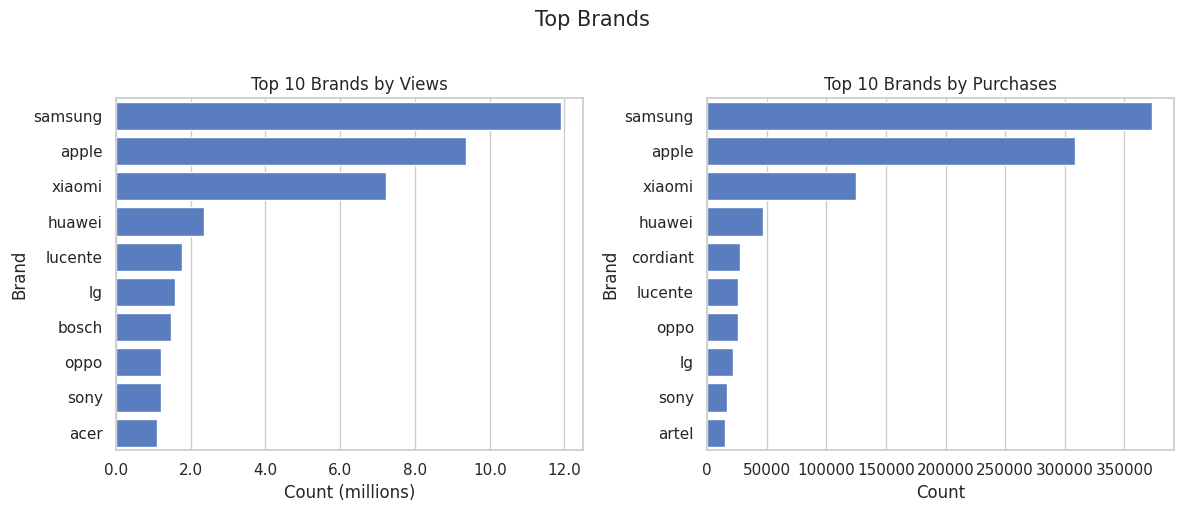

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax0 = sns.barplot(
            x=top_brand_views.values,
            y=top_brand_views.index,
            ax=axes[0])
ax1 = sns.barplot(
            x=top_brand_pur.values,
            y=top_brand_pur.index,
            ax=axes[1])

axes[0].set_title('Top 10 Brands by Views')
axes[0].set_xlabel('Count (millions)')
axes[0].xaxis.set_major_formatter(formatter)
axes[0].set_ylabel('Brand')

axes[1].set_title('Top 10 Brands by Purchases')
axes[1].set_xlabel('Count')
#axes[1].xaxis.set_major_formatter(formatter)
axes[1].set_ylabel('Brand')

plt.suptitle('Top Brands', fontsize=15, y=1.02)

plt.tight_layout()
plt.savefig('top_brands.png', dpi=300, bbox_inches='tight')
plt.show()

In [16]:
del top_brand_views, top_brand_pur
gc.collect()

17114

Samsung is the most viewed and most purchased brand, with Apple and Xiaomi following. The overlap between the top viewed and top purchased brands is high.

## Price Distribution by Event Type

Are purchased items priced differently from items that are only viewed or added to cart?

Obtain a sample of the dataset to model price distributions

In [56]:
price_sample = (
    df[['event_type', 'price']]
    .dropna(subset=['price'])
    .sample(500_000, random_state=SEED)
)

Create a density plot comparing the distributions of price for each event type (view, cart, purchase)

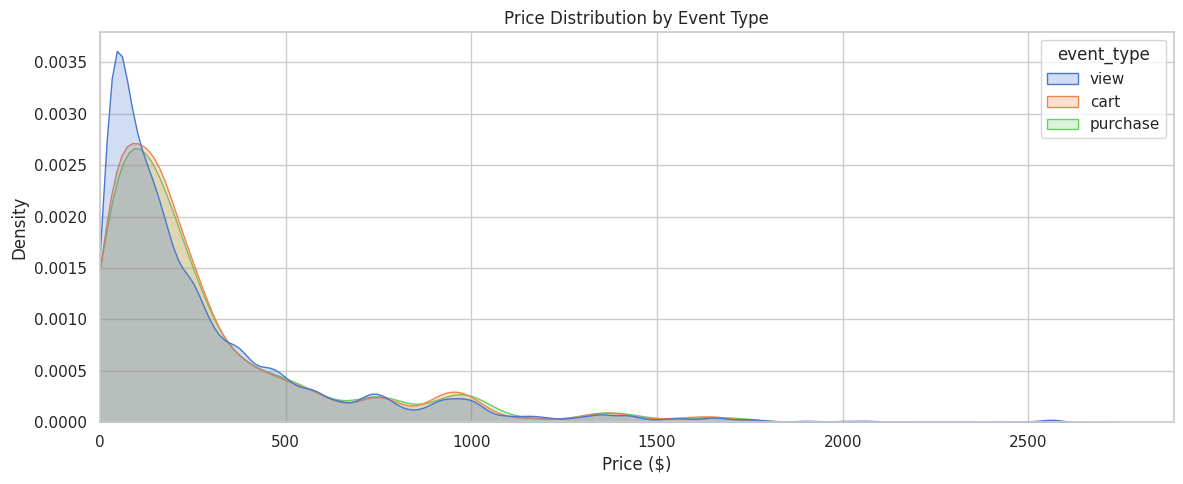

In [58]:
# Density plot of price distribution
price_dist_density = sns.kdeplot(data=price_sample, x='price', hue='event_type', fill=True, common_norm=False)

plt.xlim(0,None)
price_dist_density.set_title('Price Distribution by Event Type', fontsize=12)
price_dist_density.set_xlabel('Price ($)')

plt.tight_layout()
price_dens_fig = price_dist_density.get_figure()
price_dens_fig.savefig('price_distribution_density.png', dpi=300, bbox_inches='tight')
plt.show()

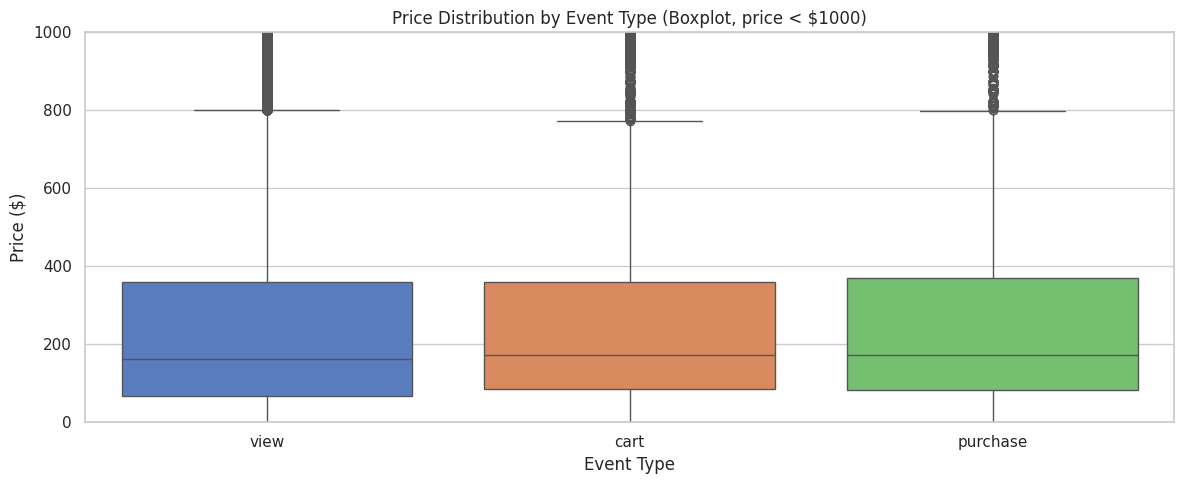

In [59]:
# Boxplot of price distribution
price_dist_bp = sns.boxplot(
    data=price_sample,
    x='event_type', y='price',
    hue='event_type',
    order=['view', 'cart', 'purchase'],
)

plt.ylim(0,1000)
price_dist_bp.set_title('Price Distribution by Event Type (Boxplot, price < $1000)', fontsize=12)
price_dist_bp.set_xlabel('Event Type')
price_dist_bp.set_ylabel('Price ($)')

plt.tight_layout()
price_bp_fig = price_dist_bp.get_figure()
price_bp_fig.savefig('price_distribution_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

In [35]:
# Summary statistics
print('\n--- Median Price by Event Type ---')
print(df.groupby('event_type')['price'].median())


--- Median Price by Event Type ---
event_type
cart        174.779999
purchase    174.020004
view        164.710007
Name: price, dtype: float32


* The median price is nearly identical across all three event types, with views being slightly lower than both carts/purchases.
* This suggests that users are more likely to interact/engage with slightly higher-priced items beyond browsing.
* All three distributions are heavily right-skewed.
* The similarity in price distribution between carts and purchases suggests that price alone is not a strong predictor of cart abandonment in this dataset.

## Summary

### Behavior Patterns
| Finding | Detail |
|---|---|
| Event distribution | ~94.3–96.1% views, ~2.1–4.4% carts, ~1.4–1.8% purchases |
| Funnel difference | Cart→Purchase conversion drops from ~80% (Oct) to ~30% (Nov), consistent with holiday browsing |
| Temporal spike | November daily activity is higher than October on average, with a large spike around 11-15 |
| Peak hours | Activity peaks in afternoon/evening UTC hours across all days |
| Top categories | Electronics leads in categories and Samsung leads for brands |
| Price pattern | Purchased items have a slightly higher median price than viewed-only items |